In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# Load dataset
df = pd.read_csv("../dataset/agro_environmental_dataset.csv")

# Cek kolom
print(df.columns)

# =========================
# FITUR & TARGET
# =========================
features = [
    'bulk_density',
    'organic_matter_pct',
    'cation_exchange_capacity',
    'salinity_ec'
]

target = 'failure_flag'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
))
])

# Train model
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train model (pakai data yang sudah balance)
pipeline.fit(X_train_resampled, y_train_resampled)

# =========================
# SIMPAN MODEL
# =========================
os.makedirs("../model", exist_ok=True)

joblib.dump(pipeline, "../model/pipeline.pkl")

print("✅ pipeline.pkl berhasil dibuat!")

Index(['location_id', 'soil_type', 'bulk_density', 'organic_matter_pct',
       'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity',
       'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet',
       'moisture_regime', 'soil_temp_c', 'air_temp_c', 'thermal_regime',
       'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm',
       'phosphorus_ppm', 'potassium_ppm', 'nutrient_balance', 'plant_category',
       'suitability_score', 'stress_level', 'failure_flag'],
      dtype='str')
✅ pipeline.pkl berhasil dibuat!


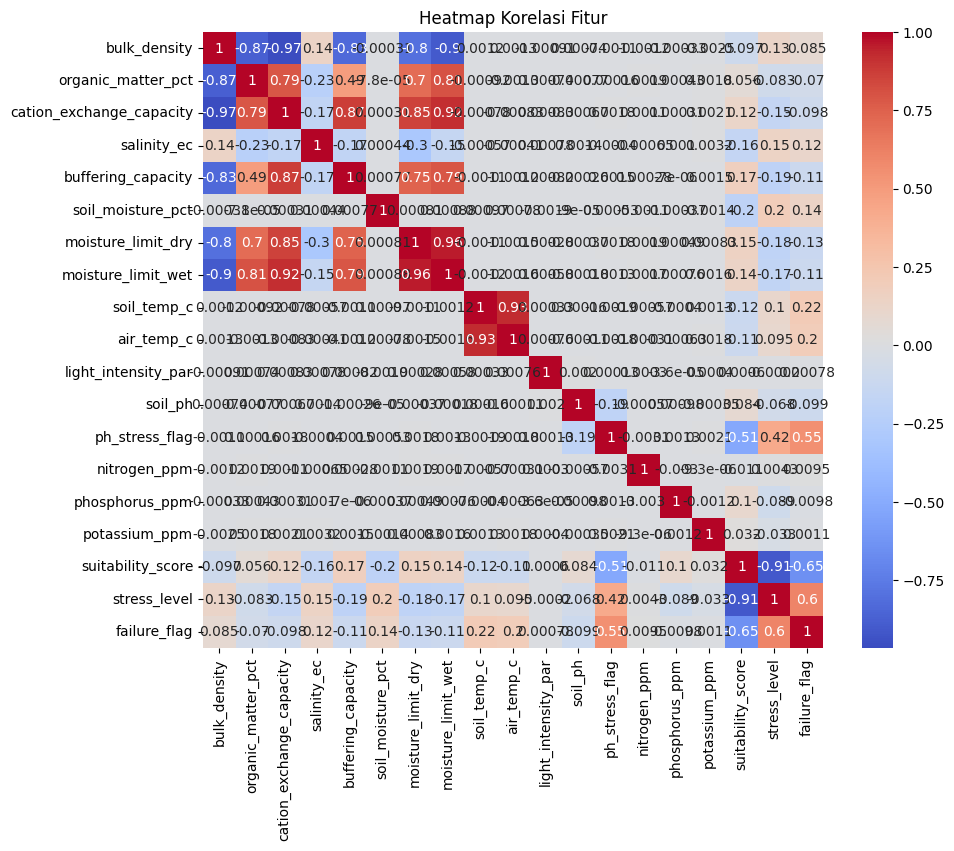

In [18]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur")
plt.show()

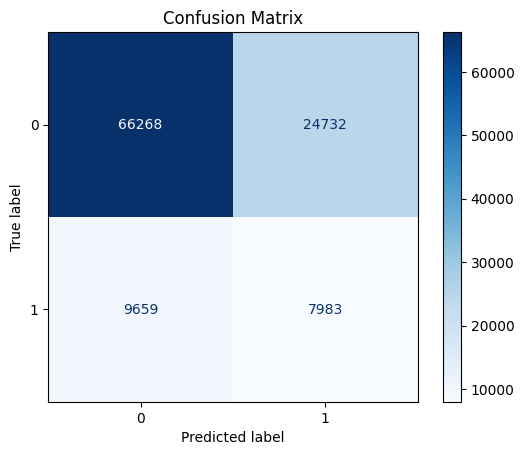


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.73      0.79     91000
           1       0.24      0.45      0.32     17642

    accuracy                           0.68    108642
   macro avg       0.56      0.59      0.56    108642
weighted avg       0.77      0.68      0.72    108642



In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = pipeline.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

# Tambahan penting
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Model 1: Random Forest
rf_model = pipeline

# Model 2: Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
lr_pipeline.fit(X_train_resampled, y_train_resampled)

# Predict
rf_pred = rf_model.predict(X_test)
lr_pred = lr_pipeline.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

Random Forest Accuracy: 0.6834
Logistic Regression Accuracy: 0.6299


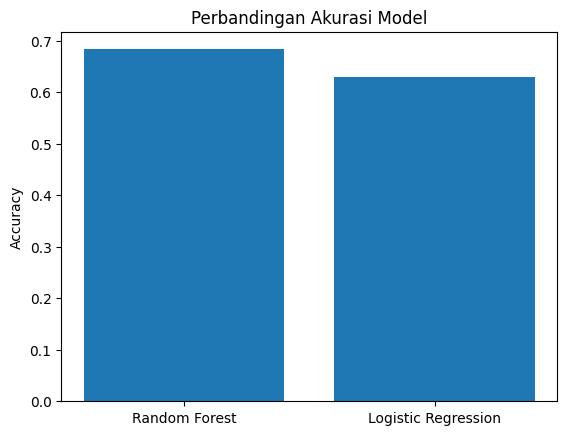

In [21]:
models = ['Random Forest', 'Logistic Regression']
scores = [rf_acc, lr_acc]

plt.bar(models, scores)
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.show()